In [1]:
import pandas as pd
import numpy as np

# Set seed for consistency
np.random.seed(7)

# Create 1,000 B2B Invoices
data = {
    'Invoice_ID': range(5001, 6001),
    'Client_Region': np.random.choice(['DACH (Germany/AT/CH)', 'Nordics', 'Southern Europe', 'UK'], 1000),
    'Invoice_Amount_EUR': np.random.randint(5000, 50000, 1000),
    'Payment_Terms_Days': np.random.choice([30, 60, 90], 1000),
    'Status': np.random.choice(['Paid On-Time', 'Late', 'Very Late'], 1000, p=[0.6, 0.3, 0.1])
}

df_finance = pd.DataFrame(data)

# Show the risk breakdown
risk_counts = df_finance['Status'].value_counts()
print("--- B2B Payment Status Breakdown ---")
print(risk_counts)

--- B2B Payment Status Breakdown ---
Status
Paid On-Time    589
Late            307
Very Late       104
Name: count, dtype: int64


In [2]:
# See which region is the most "Risky"
risk_by_region = pd.crosstab(df_finance['Client_Region'], df_finance['Status'])
print(risk_by_region)

Status                Late  Paid On-Time  Very Late
Client_Region                                      
DACH (Germany/AT/CH)    96           141         28
Nordics                 65           148         28
Southern Europe         72           146         22
UK                      74           154         26


In [3]:
# Calculate the total Euro amount "At Risk" (Late or Very Late)
at_risk_total = df_finance[df_finance['Status'] != 'Paid On-Time']['Invoice_Amount_EUR'].sum()

# Get the breakdown of total Euros by Region
region_cash_gap = df_finance.groupby('Client_Region')['Invoice_Amount_EUR'].sum().sort_values(ascending=False)

# Get only the "Very Late" amounts by Region
very_late_gap = df_finance[df_finance['Status'] == 'Very Late'].groupby('Client_Region')['Invoice_Amount_EUR'].sum()

print(f"--- TOTAL CASH FLOW RISK: €{at_risk_total:,} ---")
print("\n--- Total Invoice Volume by Region ---")
print(region_cash_gap)
print("\n--- 'Very Late' (High Risk) Amount by Region ---")
print(very_late_gap)

--- TOTAL CASH FLOW RISK: €11,396,501 ---

--- Total Invoice Volume by Region ---
Client_Region
DACH (Germany/AT/CH)    7335694
UK                      6848584
Southern Europe         6795590
Nordics                 6670758
Name: Invoice_Amount_EUR, dtype: int64

--- 'Very Late' (High Risk) Amount by Region ---
Client_Region
DACH (Germany/AT/CH)    675127
Nordics                 737459
Southern Europe         659958
UK                      650562
Name: Invoice_Amount_EUR, dtype: int64


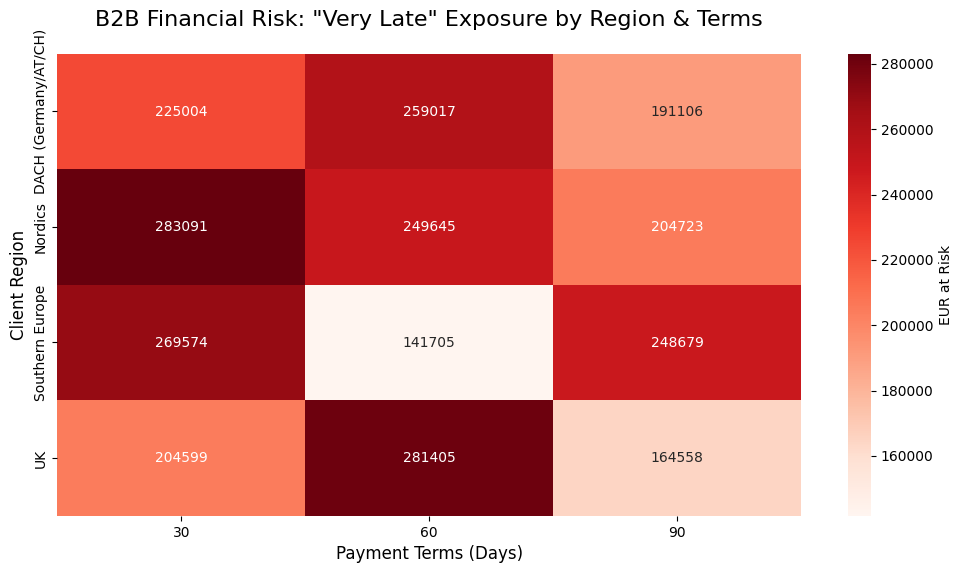

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table: Region vs Payment Terms for 'Very Late' invoices
risk_pivot = df_finance[df_finance['Status'] == 'Very Late'].pivot_table(
    index='Client_Region',
    columns='Payment_Terms_Days',
    values='Invoice_Amount_EUR',
    aggfunc='sum'
)

# Plotting the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(risk_pivot, annot=True, fmt=".0f", cmap="Reds", cbar_kws={'label': 'EUR at Risk'})

plt.title('B2B Financial Risk: "Very Late" Exposure by Region & Terms', fontsize=16, pad=20)
plt.xlabel('Payment Terms (Days)', fontsize=12)
plt.ylabel('Client Region', fontsize=12)

plt.show()